In [2]:
pip install numpy matplotlib scikit-learn scipy

Defaulting to user installation because normal site-packages is not writeable
    sys-platform (=="darwin") ; extra == 'objc'
                 ~^

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


N=188, minPts=5, epsilon=0.0550, d_max=1.2499

c1 내 평균 거리  : 0.0576
c2 내 평균 거리  : 0.1300
c1-c2 최소 거리  : 0.3364
boundary 내 거리 : 0.0818

[DBSCAN]
  클러스터 수 : 3
  노이즈 수   : 27
  ARI         : 0.8956
  Silhouette  : 0.8430

[FN-DBSCAN]
  클러스터 수 : 3
  노이즈 수   : 29
  ARI         : 0.8927
  Silhouette  : 0.8475

다르게 분류된 포인트: 2개
  pt 90     : DBSCAN= 1  FN=-1  crisp_cnt=3  w/wmax=0.0559  eps2=0.0970
  pt174[bnd]: DBSCAN= 1  FN=-1  crisp_cnt=3  w/wmax=0.0559  eps2=0.0970


/tmp/ipykernel_187451/4287208489.py:209: UserWarning: You passed a edgecolor/edgecolors ('#BDBDBD') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(pt[0], pt[1], c=col,


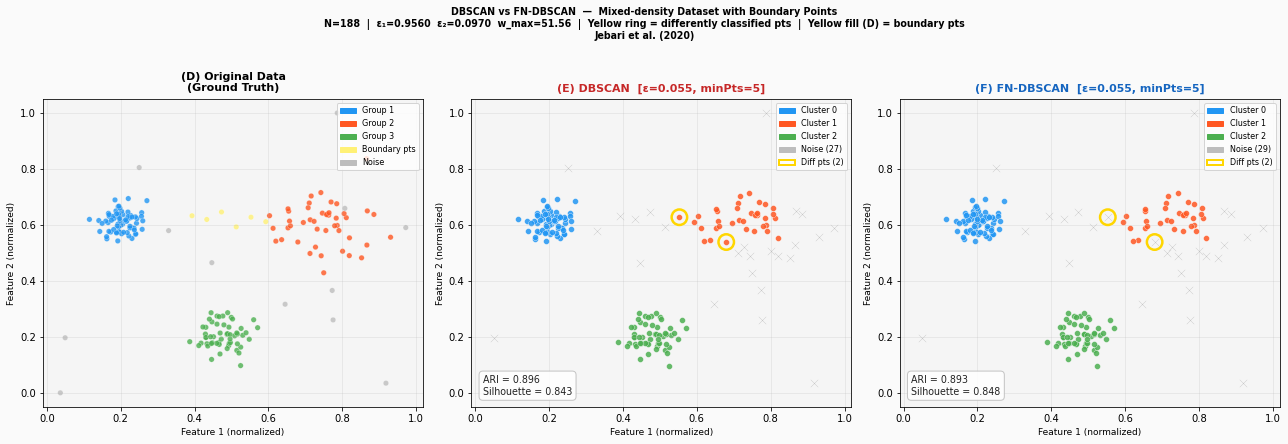

In [6]:
"""
DBSCAN vs FN-DBSCAN 비교
- 밀도가 다른 3개 클러스터 (고밀도 + 저밀도 혼합)
- 경계 근방에 고립점 배치 → 두 알고리즘의 노이즈/border 판별 차이 유도
- 평가: ARI, Silhouette Coefficient
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import cdist
from collections import deque
from sklearn.metrics import adjusted_rand_score, silhouette_score


# ──────────────────────────────────────────────
# 1. 데이터 생성
#    - c1: 고밀도 (tight)
#    - c2: 저밀도 (sparse) → epsilon 경계에서 FN/DBSCAN 판별 차이 발생
#    - c3: 중간 밀도
#    - boundary_pts: 두 클러스터 사이 고립점 (crisp=noise, fuzzy=border 가능)
# ──────────────────────────────────────────────
np.random.seed(21)

c1 = np.random.randn(70, 2) * 0.12 + [0.5, 2.0]   # 고밀도
c2 = np.random.randn(45, 2) * 0.28 + [2.5, 2.0]   # 저밀도
c3 = np.random.randn(55, 2) * 0.16 + [1.5, 0.5]   # 중간 밀도

# c1-c2 사이 경계 근방 고립점: crisp 이웃 수 부족하지만 fuzzy w_i는 충분할 수 있음
boundary = np.array([
    [1.20, 2.10], [1.35, 2.05], [1.50, 2.15],
    [1.65, 1.95], [1.80, 2.08], [1.95, 2.02],
])

noise = np.random.uniform(-0.5, 3.5, (12, 2))

data = np.vstack([c1, c2, c3, boundary, noise])
n_c1, n_c2, n_c3, n_b = len(c1), len(c2), len(c3), len(boundary)
true_labels = np.array(
    [0]*n_c1 + [1]*n_c2 + [2]*n_c3 + [3]*n_b + [-1]*len(noise)
)

# Global Min-Max 정규화
data_min = data.min(); data_max = data.max()
data_norm = (data - data_min) / (data_max - data_min)
N = len(data_norm)

D_full = cdist(data_norm, data_norm)
d_max  = D_full.max()
minPts = max(3, int(np.log(N)))

# epsilon: c1 내부 연결 O, c1-c2 직접 연결 X, boundary pts 경계에 걸치도록
epsilon = 0.055

print(f"N={N}, minPts={minPts}, epsilon={epsilon:.4f}, d_max={d_max:.4f}")

# 거리 검증
print(f"\nc1 내 평균 거리  : {cdist(data_norm[:n_c1], data_norm[:n_c1]).mean():.4f}")
print(f"c2 내 평균 거리  : {cdist(data_norm[n_c1:n_c1+n_c2], data_norm[n_c1:n_c1+n_c2]).mean():.4f}")
print(f"c1-c2 최소 거리  : {cdist(data_norm[:n_c1], data_norm[n_c1:n_c1+n_c2]).min():.4f}")
bnd_start = n_c1 + n_c2 + n_c3
print(f"boundary 내 거리 : {cdist(data_norm[bnd_start:bnd_start+n_b], data_norm[bnd_start:bnd_start+n_b]).mean():.4f}")


# ──────────────────────────────────────────────
# 2. DBSCAN
# ──────────────────────────────────────────────
def run_dbscan(data, eps, min_pts):
    N = len(data)
    D = cdist(data, data)
    adj = D <= eps
    labels = np.full(N, -2)
    cluster_id = 0
    for i in range(N):
        if labels[i] != -2:
            continue
        nb = np.where(adj[i])[0]
        if len(nb) < min_pts:
            labels[i] = -1
            continue
        labels[i] = cluster_id
        q = deque(nb)
        while q:
            j = q.popleft()
            if labels[j] == -1:
                labels[j] = cluster_id
            if labels[j] != -2:
                continue
            labels[j] = cluster_id
            nb2 = np.where(adj[j])[0]
            if len(nb2) >= min_pts:
                q.extend(nb2)
        cluster_id += 1
    return labels


# ──────────────────────────────────────────────
# 3. FN-DBSCAN
# ──────────────────────────────────────────────
def run_fn_dbscan(data, eps, min_pts, d_max):
    N = len(data)
    D = cdist(data, data)
    N_mat = np.where(D <= eps, 1.0 - D / d_max, 0.0)
    np.fill_diagonal(N_mat, 0.0)
    eps1  = 1.0 - eps / d_max
    w     = N_mat.sum(axis=1)
    w_max = w.max()
    eps2  = min_pts / w_max
    labels = np.full(N, -2)
    cluster_id = 0
    for i in range(N):
        if labels[i] != -2:
            continue
        if w[i] / w_max < eps2:
            labels[i] = -1
            continue
        labels[i] = cluster_id
        nb = np.where(N_mat[i] >= eps1)[0]
        q = deque(nb)
        while q:
            j = q.popleft()
            if labels[j] == -1:
                labels[j] = cluster_id
            if labels[j] != -2:
                continue
            labels[j] = cluster_id
            if w[j] / w_max >= eps2:
                nb2 = np.where(N_mat[j] >= eps1)[0]
                q.extend(nb2)
        cluster_id += 1
    return labels, w, eps1, eps2


# ──────────────────────────────────────────────
# 4. 실행 및 평가
# ──────────────────────────────────────────────
db_labels = run_dbscan(data_norm, epsilon, minPts)
fn_labels, w_arr, eps1, eps2 = run_fn_dbscan(data_norm, epsilon, minPts, d_max)

def evaluate(labels, true_labels, data, name):
    mask      = labels != -1
    n_cluster = len(set(labels) - {-1})
    n_noise   = (labels == -1).sum()
    ari = adjusted_rand_score(true_labels, labels)
    sil = silhouette_score(data[mask], labels[mask]) if n_cluster >= 2 and mask.sum() >= 2 else float('nan')
    print(f"\n[{name}]")
    print(f"  클러스터 수 : {n_cluster}")
    print(f"  노이즈 수   : {n_noise}")
    print(f"  ARI         : {ari:.4f}")
    print(f"  Silhouette  : {sil:.4f}")
    return ari, sil, n_cluster, n_noise

ari_db, sil_db, nc_db, nn_db = evaluate(db_labels, true_labels, data_norm, "DBSCAN")
ari_fn, sil_fn, nc_fn, nn_fn = evaluate(fn_labels, true_labels, data_norm, "FN-DBSCAN")

diff_pts = np.where(db_labels != fn_labels)[0]
print(f"\n다르게 분류된 포인트: {len(diff_pts)}개")
for idx in diff_pts[:15]:
    adj_row = D_full[idx] <= epsilon; adj_row[idx] = False
    is_bnd  = bnd_start <= idx < bnd_start + n_b
    print(f"  pt{idx:3d}{'[bnd]' if is_bnd else '     '}: "
          f"DBSCAN={db_labels[idx]:2d}  FN={fn_labels[idx]:2d}  "
          f"crisp_cnt={adj_row.sum()}  "
          f"w/wmax={w_arr[idx]/w_arr.max():.4f}  eps2={eps2:.4f}")


# ──────────────────────────────────────────────
# 5. 시각화: D, E, F
# ──────────────────────────────────────────────
CLUSTER_COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800']
NOISE_COLOR    = '#BDBDBD'
BND_COLOR      = '#FFF176'   # boundary pts 강조색

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#FAFAFA')
plt.subplots_adjust(wspace=0.30, left=0.04, right=0.98, top=0.83, bottom=0.10)

def plot_panel(ax, data, labels, title, title_color='black',
               true_labels=None, diff_pts=None,
               ari=None, sil=None, nn=None):

    if true_labels is not None:
        # (D) 원본
        colors = []
        for i, l in enumerate(true_labels):
            if bnd_start <= i < bnd_start + n_b:
                colors.append(BND_COLOR)       # boundary pts 별도 색
            elif l >= 0:
                colors.append(CLUSTER_COLORS[l])
            else:
                colors.append(NOISE_COLOR)
        ax.scatter(data[:, 0], data[:, 1],
                   c=colors, s=30, alpha=0.80, edgecolors='white', lw=0.3)
        patches = [mpatches.Patch(color=CLUSTER_COLORS[i], label=f'Group {i+1}')
                   for i in range(3)]
        patches += [mpatches.Patch(color=BND_COLOR, label='Boundary pts')]
        patches += [mpatches.Patch(color=NOISE_COLOR, label='Noise')]
        ax.legend(handles=patches, fontsize=8, loc='upper right')

    else:
        # (E), (F) 알고리즘 결과
        unique = sorted(set(labels) - {-1})
        cmap   = {cid: CLUSTER_COLORS[i % len(CLUSTER_COLORS)]
                  for i, cid in enumerate(unique)}
        for i, pt in enumerate(data):
            lbl = labels[i]
            col = cmap.get(lbl, NOISE_COLOR)
            mk  = 'x' if lbl == -1 else 'o'
            ax.scatter(pt[0], pt[1], c=col,
                       s=35 if lbl != -1 else 55,
                       marker=mk, alpha=0.85,
                       edgecolors='white' if lbl != -1 else col, lw=0.4)
        if diff_pts is not None and len(diff_pts):
            ax.scatter(data[diff_pts, 0], data[diff_pts, 1],
                       s=240, facecolors='none', edgecolors='#FFD600',
                       linewidths=2.5, zorder=6)
        plist  = [mpatches.Patch(color=cmap[c], label=f'Cluster {c}')
                  for c in unique]
        plist += [mpatches.Patch(color=NOISE_COLOR, label=f'Noise ({nn})')]
        if diff_pts is not None and len(diff_pts):
            plist += [mpatches.Patch(facecolor='none', edgecolor='#FFD600',
                                     linewidth=2,
                                     label=f'Diff pts ({len(diff_pts)})')]
        ax.legend(handles=plist, fontsize=8, loc='upper right')

        score_txt = f"ARI = {ari:.3f}\nSilhouette = {sil:.3f}"
        ax.text(0.03, 0.04, score_txt, transform=ax.transAxes,
                fontsize=9.5, color='#222',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          alpha=0.85, edgecolor='#BBBBBB'))

    ax.set_title(title, fontsize=11, fontweight='bold',
                 color=title_color, pad=8)
    ax.set_xlabel('Feature 1 (normalized)', fontsize=9)
    ax.set_ylabel('Feature 2 (normalized)', fontsize=9)
    ax.set_facecolor('#F5F5F5')
    ax.grid(True, alpha=0.25)


plot_panel(axes[0], data_norm, None,
           '(D) Original Data\n(Ground Truth)',
           true_labels=true_labels)

plot_panel(axes[1], data_norm, db_labels,
           f'(E) DBSCAN  [ε={epsilon}, minPts={minPts}]',
           title_color='#C62828',
           diff_pts=diff_pts, ari=ari_db, sil=sil_db, nn=nn_db)

plot_panel(axes[2], data_norm, fn_labels,
           f'(F) FN-DBSCAN  [ε={epsilon}, minPts={minPts}]',
           title_color='#1565C0',
           diff_pts=diff_pts, ari=ari_fn, sil=sil_fn, nn=nn_fn)

fig.suptitle(
    'DBSCAN vs FN-DBSCAN  —  Mixed-density Dataset with Boundary Points\n'
    f'N={N}  |  ε₁={eps1:.4f}  ε₂={eps2:.4f}  w_max={w_arr.max():.2f}  '
    f'|  Yellow ring = differently classified pts  '
    f'|  Yellow fill (D) = boundary pts\n'
    'Jebari et al. (2020)',
    fontsize=9.5, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('dbscan_vs_fn_dbscan_DEF.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()